In [1]:
import numpy as np

import torch
import torchvision
from torchvision import datasets , transforms , models
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

import random as rnd
import time
from pprint import pprint
import os

from sklearn.metrics import confusion_matrix , classification_report

### Κώδικας και Εργασία 1
Το μεγαλύτερο μέρος του κώδικα είναι απευθείας αντογραφή από την Εργασία 1. Όλες οι συναρτήσεις έως και τον ορισμό της κλάσης MLP_Hinge είναι πανομοιότυπες. Η μόνη αλλαγή που χρειάστηκε, είναι στην συνάρτηση Train_Model, όπου το Criterion ορίζεται πλέον ως criterion = nn.MultiMarginLoss(margin = 1.0).

In [2]:
configuration = {

    #Device selection and download path. Adjust accordinglly.
    "device" : "cuda" if torch.cuda.is_available() else "cpu" ,
    "root" :  r"C:\Users\dimit\Desktop\Νευρωνικά\Εργασία 1" ,

    #Batch size and shuffle. These are used by the Data Loaders.
    "batch_size" : 128 ,
    "shuffle" : True ,

#Data Augmentation segment.
    #Random crop parameters that affect the magnitude of the shift.
    "random_crop" : {
        "flag" : True ,
        #Size of final image.
        "size" : 32 ,
        #Added pixels in each direction. Total image is 40x40.
        "padding" : 4 ,
        #Mode -> Reflect uses the border content of the image to fill the padding. Not zeros,
        #ones or any other fixed value.
        "mode" : "reflect" ,
        
    } ,

    #Horizontal flip sub-dictionary.
    "horizontal_flip" : {
        "flag" : True ,
        #Probability that an image is flipped.
        "probability" : 0.5 ,
    } ,

    #Colour Jitter sub-dictionary.
    "jitter" : {
        "flag" : True ,
        #The follwing values scale the corresponding colour aspect of the image in the
        #[1 - value , 1 + value] range.
        "brightness" : 0.15 ,
        "contrast" : 0.15 , 
        "saturation" : 0.15 , 
        "hue" : 0.05 ,
    } , 

    #Random Erasing sub-dictionary.
    "erasing" : {
        "flag" : True , 
        #The specified probability of the erasure.
        "probability" : 0.2 ,
    } ,

#Neuranl Network parameter segment.
    #Width of the Netwok.
    "channels" : [32 , 32 , 32] ,
    #Activation function selection. Only ReLU and Leaky ReLU are supported.
    "activation_function" : "relu" , 
    #Dropout value. Shuts neurons off accordignly.
    "dropout" : 0.2 , 

    #Learning Rate and Weight Decay instruct the Optimizer. Only Adam is used.
    #These values are typical for Adam.
    "learning_rate" : 1e-3 , 
    "weight_decay" : 1e-3 , 
    #Number of epochs.
    "epochs" : 60 , 
    #Scheduler subdictionary.
    "scheduler" : {
        #Only Step and Multistep are supported.
        "type" : "step" , 
        #Number of epochs after which to reduce LR.
        "step_size" : 20 , 
        #Multiplication factor selection after Scheduler activation.
        "gamma" : 0.1 , 
        #Only for Multistep.
        "milestones" : [50 , 100] , 
    } ,

    #Batch Normalization flag.
    "batch_normalization" : True ,
}


#Maximum accuracy achieved: 

In [3]:
training_set = datasets.CIFAR10(
    root = configuration["root"],
    #Designates data as Training.
    train = True,
    download = True,
    transform = None
)

test_set = datasets.CIFAR10(
    root = configuration["root"],
    #Designates Data as Testing.
    train = False,
    download = True,
    transform = None
)

In [4]:
training_images = training_set.data.astype(np.float32) / 255.0

mean = tuple(training_images.mean(axis = (0 , 1 , 2)).tolist())
std = tuple(training_images.std(axis = (0 , 1 , 2)).tolist())

print("Per channel mean : ", mean , "\n")
print("Per channel STD : ", std , "\n")

Per channel mean :  (0.49140089750289917, 0.48215895891189575, 0.4465307891368866) 

Per channel STD :  (0.2470327913761139, 0.243484228849411, 0.261587530374527) 



In [5]:
def Data_Augmentations(configuration , mean , std):

    #Pre-allocate training transforms as empty list.
    training_transforms = []

    #Extract the random_crop dictionary from configuration.
    crop = configuration["random_crop"]

    #Append said transform if flag is set to True.
    if crop["flag"]:
        training_transforms.append(
            #We use the built-in Pytorch Module RandomCrop.
            #The values are extracted from the crop dictionary.
            transforms.RandomCrop(size = crop["size"] , 
                                 padding = crop["padding"] ,
                                 padding_mode = crop["mode"])
        )

    #Very similar process for Random Horizontal Flip and Colour Jittering.
    #Again, the corresponding sub-dictionaries are extracted and the built-in modules are
    #called.
    flip = configuration["horizontal_flip"]

    if flip["flag"]:
        training_transforms.append(
            transforms.RandomHorizontalFlip(p = flip["probability"])
        )

    jitter = configuration["jitter"]

    if jitter["flag"]:
        training_transforms.append(
            transforms.ColorJitter(brightness = jitter["brightness"] , 
                                  contrast = jitter["contrast"] , 
                                  saturation = jitter["saturation"] ,
                                  hue = jitter["hue"])
        )

    #Append Tensor Conversion and Normalization Transforms as well.
    training_transforms.append(transforms.ToTensor())
    training_transforms.append(transforms.Normalize(mean , std))

    #Extract Random Erasing sub-dict.
    erase = configuration["erasing"]

    #Apply if flag is set to True. Again, using the built-in module.
    if erase["flag"]:
        training_transforms.append(transforms.RandomErasing(p = erase["probability"]))

    #Use Compose to turn list into callable object.
    composed_training_transforms = transforms.Compose(training_transforms)

    #Apply only Tensor Conversion and Normalization to test data.
    testing_transforms = []

    testing_transforms.append(transforms.ToTensor())
    testing_transforms.append(transforms.Normalize(mean , std))

    #Compose second callable object and return.
    composed_testing_transforms = transforms.Compose(testing_transforms)

    return composed_training_transforms , composed_testing_transforms


def Build_Dataloaders(configuration , training_set , test_set):
    #Call the buit-in DataLoader method for the traning set.
    training_dataloader = DataLoader(training_set , 
                                     batch_size = configuration["batch_size"] ,
                                    shuffle = configuration["shuffle"])
    #Same process for test set.
    testing_dataloader = DataLoader(test_set , 
                                   batch_size = configuration["batch_size"] , 
                                   shuffle = False)

    return training_dataloader , testing_dataloader


def Training_Epoch(model , dataloader , optimizer , criterion , configuration):

    device = configuration["device"]
    #Set model to training mode. 
    model.train()

    #Initialize counters.
    running_loss = 0.0
    correct = 0
    total = 0

    #Iterate through Data Loader.
    for images , labels in dataloader:
        #Load batch of images and labels.
        images = images.to(device)
        labels = labels.to(device)
        #Reset Gradients. 
        optimizer.zero_grad()
        #Forward pass: work through model pipeline and classify.
        output = model(images)
        #Calculate loss by comparing predictions to actual labels. Almost always Cross Entropy Loss.
        loss = criterion(output , labels)
        #Backwards Pass (Back Propagate): compute gradients with regard to all params. 
        loss.backward()
        #Call optimizer to update weights.
        optimizer.step()

        #Calculate average loss per image and multiply by number of images in batch.
        running_loss += loss.item() * images.size(0)
        #Get predicted class per sample.
        _ , predictions = output.max(1)
        #Calculate number of correct predictions in batch and add to total number of 
        #correct predictions.
        correct += (predictions == labels).sum().item()
        #Add number of current batch samples to number of total samples for this epoch.
        total += labels.size(0)
    #Extract the per-epoch stats.
    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss , epoch_accuracy


def Evaluate(model , dataloader , criterion , configuration):

    device = configuration["device"]
    #Switch to evaluation mode.
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0
    #Use no_grad() to relieve memory from gradient storing.
    with torch.no_grad():
        #Iterate through dataloader for all mini batches.
        for images , labels in dataloader:
            #Load samples and labels.
            images = images.to(device)
            labels = labels.to(device)
            #Predict.
            outputs = model(images)
            #calculate loss.
            loss = criterion(outputs , labels)
            #Extract statistic like before.
            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    #Calculate across-epoch statistics.
    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss , epoch_accuracy


def Train_Model(model , training_dataloader , test_dataloader , configuration , optimizer , scheduler = None , criterion = None):

    device = configuration["device"]
    
    #Cross Entropy Loss is selected unless told other wise.
    #The function handle for criterion defaults to None.
    if criterion is None:
        criterion = nn.MultiMarginLoss(margin = 1.0)
    
    #Get number of epochs from configuration.
    epochs = configuration["epochs"]
    
    #Create dictionary of empty lists to store losses and acurracies.
    performance = {
        "training_loss" : [] , 
        "training_accuracy" : [] , 
        "testing_loss" : [] , 
        "testing_accuracy" : []
    }
    
    best_accuracy = 0.0
    best_state = None
    
    #Get start time.
    start = time.time()
    
    #Train for number of required epochs.
    for epoch in range(epochs):
        
        #Get training loss and accuracy by calling Training_Epoch.
        #This also trains the model, as we saw earlier.
        training_loss , training_accuracy = Training_Epoch(model , training_dataloader , optimizer , criterion , configuration)
        
        #Evaluate model. No changes are done at all in this step.
        testing_loss , testing_accuracy = Evaluate(model , test_dataloader , criterion , configuration)
        
        #Call scheduler in case it needs to step in. Would be the same to just
        #call scheduler.step() but anyway.
        Scheduler(scheduler , configuration)
        
        #Append metrics to corresponding category.
        performance["training_loss"].append(training_loss)
        performance["training_accuracy"].append(training_accuracy)
        performance["testing_loss"].append(testing_loss)
        performance["testing_accuracy"].append(testing_accuracy)

        #Check for improved accuracy. If so, update best_state.
        #Again, we judge based on performance on test data.
        if testing_accuracy > best_accuracy:
            best_accuracy = testing_accuracy
            best_state = model.state_dict()

        #Print epoch results.
        print(  f"Epoch [{epoch+1} / {epochs}]"
                f"Training Loss: {training_loss: .4f} | Training Accuracy: {training_accuracy * 100 : .2f}%"
                f"Test Loss {testing_loss: .4f} | Test Accuracy: {testing_accuracy * 100 : .2f}%")
    #Calculate total training time.
    total_time = time.time() - start

    #Print training time and best achieved accuracy.
    print(f"\nBest accuracy: {best_accuracy * 100 : .2f}%")
    print(f"Total Training Time: {total_time / 60: .1f} minutes.")

    #Return history and state.
    return performance , best_state


def Build_Adam(configuration , model):
    #Call optim.Adam to create optimizer object.
    optimizer = optim.Adam(model.parameters() , 
                          lr = configuration["learning_rate"] , 
                          weight_decay = configuration["weight_decay"]
                          )

    return optimizer


def Build_Scheduler(configuration , optimizer):

    #Get scheduler configuration sub-dictionary.
    scheduler_configuration = configuration.get("scheduler" , None)

    #If None, return None.
    if scheduler_configuration is None:
        return None

    #Get type.
    scheduler_type = scheduler_configuration.get("type" , "none").lower()

    #If type is set to "none", return None.
    if scheduler_type == "none":
        return None

    #Create Step Scheduler object through the built-in PyTorch method.
    if scheduler_type == "step":
        scheduler = optim.lr_scheduler.StepLR(
            optimizer , 
            step_size = scheduler_configuration["step_size"] , 
            gamma = scheduler_configuration["gamma"]
        )
        return scheduler

    #Create MultiStep Scheduler object through the Built-In Pytorch method.
    if scheduler_type == "multistep":
        scheduler = optim.lr_scheduler.MultiStepLR(
            optimizer , 
            milestones = scheduler_configuration["milestones"] ,
            gamma = scheduler_configuration["gamma"]
        )
        return scheduler

    #Else, raise a Value Error to indicate incorrect selection.
    raise ValueError("Invalid Scheduler Type. Check configuration.")


def Training_Curve(performance):

    epochs = range(1 , len(performance["training_loss"]) + 1)

    #Plot Loss curves for training and Testing.
    plt.figure()
    plt.plot(epochs , performance["training_loss"] , label = "Training Loss")
    plt.plot(epochs , performance["testing_loss"], label = "Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    #Plot Accuracy curves for training and testing.
    plt.figure()
    plt.plot(epochs , performance["training_accuracy"] , label = "Training Accuracy")
    plt.plot(epochs , performance["testing_accuracy"] , label = "Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Test Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


def Predictions(model , dataloader , configuration):

    device = configuration["device"]
    #Switch on evaluation mode.
    model.eval()

    #Preallocate labels and predictions.
    labels = []
    predictions = []

    #Use no_grad() for efficiency.
    with torch.no_grad():

        #Similar loop as shown in Evaluate().
        for image , label in dataloader:
            image = image.to(device)
            #Get predictions.
            output = model(image)
            _ , prediction = output.max(1)

            #Append batch labels and predictions to corresponding lists.
            labels.append(label.numpy())
            predictions.append(prediction.cpu().numpy())
    
    #Merge all batches to single arrays.
    true_labels = np.concatenate(labels)
    predicted_labels = np.concatenate(predictions)

    return true_labels , predicted_labels


def Model_Statistics(model , dataloader , configuration ,  print_report = True):

    #Get class names as to not show just the label numbers.
    class_names = dataloader.dataset.classes

    #Call Predictions to get true and predicted labels.
    true_labels , predicted_labels = Predictions(model , dataloader , configuration)

    #Use SickitLearn's built-in module to create the Confusion Matrix.
    cm = confusion_matrix(true_labels , predicted_labels)

    #Create the classification report by passing the results and the class names. 
    #Store it as dictionary.
    report = classification_report(
        true_labels , 
        predicted_labels ,
        target_names = class_names ,
        output_dict = True
    )

    overall_accuracy = report["accuracy"]

    #Print the results.
    print(f"\n Overall accuracy: {overall_accuracy * 100: .2f}% \n")
    print("Classification Report: \n")
    print(classification_report(true_labels , 
                                predicted_labels ,
                                target_names = class_names ,
                                output_dict = False))

    #Print the confusion matrix.
    Plot_CM(cm , class_names)


def Plot_CM(cm , class_names):

    fmt = "d"
    
    plt.figure(figsize = (8 , 8))
    plt.imshow(cm , interpolation = "nearest" , cmap = "Blues")
    plt.title("Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks , class_names , rotation = 45)
    plt.yticks(tick_marks , class_names)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            plt.text(
                j, i,
                format(value, fmt),
                ha="center", va="center",
                color="white" if value > thresh else "black"
            )
    
    
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

def Scheduler(scheduler , configuration):
    #Redundant.
    if scheduler is None:
        return
    #Redundant.
    scheduler_config = configuration.get("scheduler" , {})
    scheduler_type = scheduler_config.get("type" , "none").lower()
    #Instruct Scheduler to take a step.
    scheduler.step()

#### Το Δίκτυο.
Ορίζεται ως Python Class, όπως είχε γίνει και για το CNN.

In [15]:
class MLP_Hinge(nn.Module):
    #Hidden layer is defaulted to 512 Neurons.
    #Dropout also defaulted at 20%.
    def __init__(self, hidden_dim = 512 , dropout = 0.2, num_classes = 10 , use_bn = True):
        super().__init__()
        #The pipeline. First flatten to (N , 3072). We know that N is 50.000 images.
        layers = [
            nn.Flatten(),
            #Define the hidden layer.
            nn.Linear(3*32*32, hidden_dim),
        ]
        if use_bn:
            #Append Batch Normalization in layers if needed.
            layers.append(nn.BatchNorm1d(hidden_dim))
        layers += [
            #Activation Layer
            nn.ReLU(inplace = True),
            #Shut Neurons Off.
            nn.Dropout(dropout),
            #Linear output layer.
            nn.Linear(hidden_dim , num_classes) 
        ]
        #Pack layers to a single module.
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

#### Εκπαίδευση.
Το παρακάτων πείραμα δεν διαφέρει σε φιλοσοφία και υλοποίηση από αυτό της Εργασίας 1. Τα σχόλια παραλείπονται.

Epoch [1 / 60]Training Loss:  0.4997 | Training Accuracy:  33.18%Test Loss  0.3996 | Test Accuracy:  41.47%
Epoch [2 / 60]Training Loss:  0.4557 | Training Accuracy:  36.10%Test Loss  0.3879 | Test Accuracy:  42.84%
Epoch [3 / 60]Training Loss:  0.4430 | Training Accuracy:  37.39%Test Loss  0.3885 | Test Accuracy:  41.85%
Epoch [4 / 60]Training Loss:  0.4390 | Training Accuracy:  37.52%Test Loss  0.3747 | Test Accuracy:  44.28%
Epoch [5 / 60]Training Loss:  0.4379 | Training Accuracy:  37.40%Test Loss  0.3738 | Test Accuracy:  43.79%
Epoch [6 / 60]Training Loss:  0.4372 | Training Accuracy:  37.46%Test Loss  0.3664 | Test Accuracy:  44.32%
Epoch [7 / 60]Training Loss:  0.4339 | Training Accuracy:  37.59%Test Loss  0.3682 | Test Accuracy:  43.76%
Epoch [8 / 60]Training Loss:  0.4337 | Training Accuracy:  37.59%Test Loss  0.3665 | Test Accuracy:  43.75%
Epoch [9 / 60]Training Loss:  0.4302 | Training Accuracy:  38.09%Test Loss  0.3583 | Test Accuracy:  44.22%
Epoch [10 / 60]Training Loss

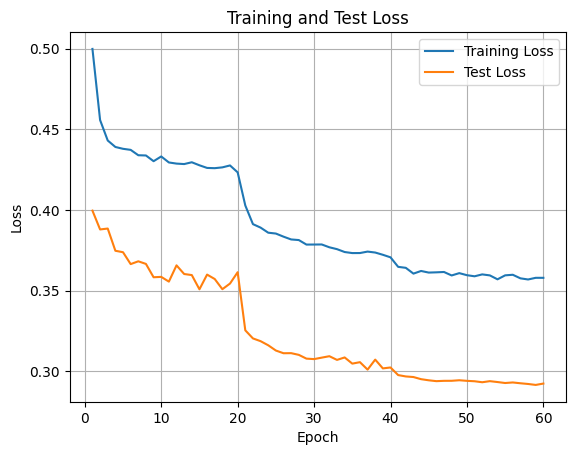

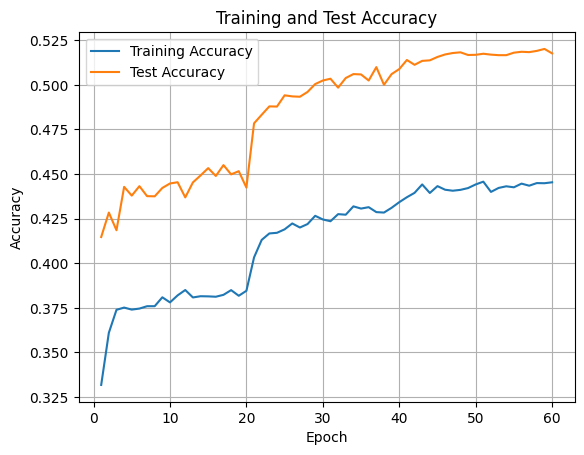


 Overall accuracy:  51.76% 

Classification Report: 

              precision    recall  f1-score   support

    airplane       0.57      0.57      0.57      1000
  automobile       0.61      0.64      0.62      1000
        bird       0.41      0.33      0.36      1000
         cat       0.39      0.32      0.35      1000
        deer       0.47      0.44      0.45      1000
         dog       0.44      0.40      0.42      1000
        frog       0.50      0.65      0.57      1000
       horse       0.58      0.59      0.58      1000
        ship       0.60      0.69      0.64      1000
       truck       0.54      0.56      0.55      1000

    accuracy                           0.52     10000
   macro avg       0.51      0.52      0.51     10000
weighted avg       0.51      0.52      0.51     10000



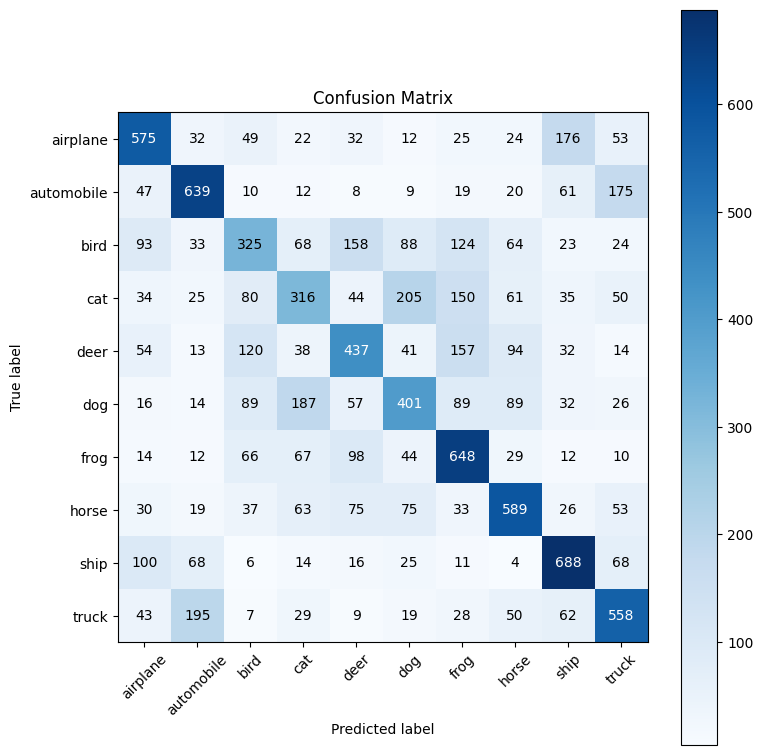

In [9]:
device = configuration["device"]

train_transforms , test_transforms = Data_Augmentations(configuration , mean , std)

training_set.transform = train_transforms
test_set.transform = test_transforms

train_loader, test_loader = Build_Dataloaders(configuration, training_set, test_set)

model = MLP_Hinge(
    hidden_dim=512,
    dropout=configuration["dropout"],
    num_classes=10,
    use_bn=configuration["batch_normalization"]
).to(device)

optimizer = Build_Adam(configuration, model)
scheduler = Build_Scheduler(configuration, optimizer)

performance, best_state = Train_Model(
    model=model,
    training_dataloader = train_loader,
    test_dataloader = test_loader,
    configuration = configuration,
    optimizer = optimizer,
    scheduler = scheduler,
    criterion = None)

model.load_state_dict(best_state)
Training_Curve(performance)
Model_Statistics(model, test_loader, configuration)


torch.save(performance , "nn_performance_2.pth")
torch.save(best_state , "nn_state_2.pth")

